<a href="https://colab.research.google.com/github/nile-therese/internship_2026/blob/main/CNN_VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required libraries

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

Load and sample fashion_mnist dataset

In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [20]:
x_train,y_train=x_train[:100],y_train[:100]
x_test,y_test=x_test[:100],y_test[:100]

Resize images to 224*224

In [21]:
x_train=tf.image.resize(x_train,(224,224))
x_test=tf.image.resize(x_test,(224,224))

Normalization

In [22]:
x_train=x_train/255.0
x_test=x_test/255.0


One hot encoding

In [23]:
(_,y_train_full),(_,y_test_full)=tf.keras.datasets.fashion_mnist.load_data()
y_train=y_train_full[:100]
y_test=y_test_full[:100]
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

Load pretrained VGG16 without top layers

In [24]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

Freeze basemodel layers(feature extraction)

In [25]:
for layer in base_model.layers:
  layer.trainable=False

Add custom top layers

In [26]:
x=base_model.output
x=Flatten()(x)
x=Dense(256,activation='relu')(x)
x=Dropout(0.5)(x)
predictions=Dense(10,activation='softmax')(x)

Create the finsl model

In [27]:
model=Model(inputs=base_model.input,outputs=predictions)

Compile the model(feature extraction phase)

In [28]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

Train the model(only top layers)

In [29]:
((raw_x_train, raw_y_train), (_, _)) = tf.keras.datasets.fashion_mnist.load_data()


x_train_subset = raw_x_train[:100]
y_train_subset = raw_y_train[:100]


x_train_processed = tf.cast(x_train_subset, tf.float32) / 255.0
x_train_processed = tf.expand_dims(x_train_processed, axis=-1)
x_train_processed = tf.image.resize(x_train_processed, (224, 224))
x_train_processed = tf.image.grayscale_to_rgb(x_train_processed)


y_train_processed = to_categorical(y_train_subset)

print(f"shape of x_train_processed before model.fit: {x_train_processed.shape}")
print(f"shape of y_train_processed before model.fit: {y_train_processed.shape}")

history = model.fit(x_train_processed, y_train_processed, batch_size=32, epochs=5, validation_split=0.2)

shape of x_train_processed before model.fit: (100, 224, 224, 3)
shape of y_train_processed before model.fit: (100, 10)
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.1375 - loss: 2.6503 - val_accuracy: 0.2000 - val_loss: 2.2612
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.1625 - loss: 2.3277 - val_accuracy: 0.3500 - val_loss: 1.9539
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.3750 - loss: 1.8817 - val_accuracy: 0.5500 - val_loss: 1.7661
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 0.4500 - loss: 1.6579 - val_accuracy: 0.5500 - val_loss: 1.6578
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.5750 - loss: 1.4540 - val_accuracy: 0.5500 - val_loss: 1.5284


Fine-true some convolutional layers

In [30]:
for layer in base_model.layers[-4:]:
  layer.trainable=True

Compile again(after unfreezing)

In [31]:
model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

In [32]:
((raw_x_train, raw_y_train), (_, _)) = tf.keras.datasets.fashion_mnist.load_data()


x_train_subset = raw_x_train[:100]
y_train_subset = raw_y_train[:100]


x_train_fine = tf.cast(x_train_subset, tf.float32) / 255.0
x_train_fine = tf.expand_dims(x_train_fine, axis=-1)
x_train_fine = tf.image.resize(x_train_fine, (224, 224))
x_train_fine = tf.image.grayscale_to_rgb(x_train_fine)


y_train_fine = to_categorical(y_train_subset)

print(f"shape of x_train_fine before model.fit: {x_train_fine.shape}")
print(f"shape of y_train_fine before model.fit: {y_train_fine.shape}")

history_fine = model.fit(x_train_fine, y_train_fine, batch_size=32, epochs=5, validation_split=0.2)

shape of x_train_fine before model.fit: (100, 224, 224, 3)
shape of y_train_fine before model.fit: (100, 10)
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6500 - loss: 1.2213 - val_accuracy: 0.6500 - val_loss: 1.3667
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step - accuracy: 0.6125 - loss: 1.1345 - val_accuracy: 0.7000 - val_loss: 1.2407
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.7500 - loss: 0.9709 - val_accuracy: 0.6500 - val_loss: 1.1404
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - accuracy: 0.8500 - loss: 0.7574 - val_accuracy: 0.6500 - val_loss: 1.0568
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.8875 - loss: 0.7202 - val_accuracy: 0.7500 - val_loss: 0.9852


Evaluate on test set

In [33]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
((raw_x_test, raw_y_test), (_, _)) = tf.keras.datasets.fashion_mnist.load_data()


x_test_subset = raw_x_test[:100]
y_test_subset = raw_y_test[:100]


x_test_processed = tf.cast(x_test_subset, tf.float32) / 255.0
x_test_processed = tf.expand_dims(x_test_processed, axis=-1)
x_test_processed = tf.image.resize(x_test_processed, (224, 224))
x_test_processed = tf.image.grayscale_to_rgb(x_test_processed)


y_test_processed = to_categorical(y_test_subset)

print(f"shape of x_test_processed before model.fit: {x_test_processed.shape}")
print(f"shape of y_test_processed before model.fit: {y_test_processed.shape}")

test_loss,test_acc=model.evaluate(x_test_processed, y_test_processed)
print("Test accuracy",test_acc)
print("Test loss",test_loss)


shape of x_test_processed before model.fit: (100, 224, 224, 3)
shape of y_test_processed before model.fit: (100, 10)
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - accuracy: 0.9100 - loss: 0.6654
Test accuracy 0.9100000262260437
Test loss 0.6653666496276855


Plot accuracy graph

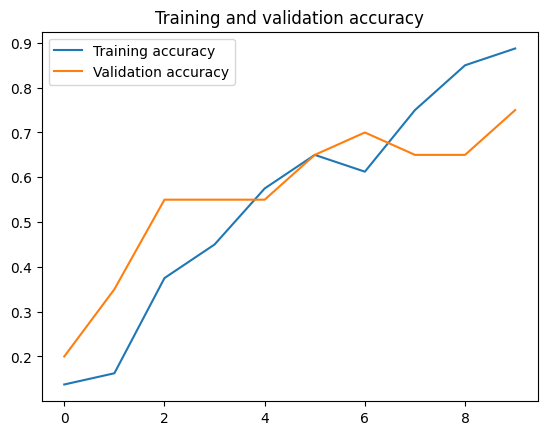

In [34]:
plt.plot(history.history['accuracy']+history_fine.history['accuracy'],label='Training accuracy')
plt.plot(history.history['val_accuracy']+history_fine.history['val_accuracy'],label='Validation accuracy')
plt.legend()
plt.title('Training and validation accuracy')
plt.show()